In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [19]:
df = pd.read_csv('../dataset/paysim_data.csv', nrows=500000)

In [20]:
df.sample(5)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
189294,13,TRANSFER,649453.05,C1030619756,0.0,0.00,C217441120,2086453.28,2735906.33,0,0
330263,16,PAYMENT,7107.73,C746439734,237236.9,230129.17,M1891973971,0.00,0.00,0,0
209746,13,CASH_IN,85333.60,C63011792,40279.0,125612.60,C834276080,0.00,0.00,0,0
137867,11,PAYMENT,37962.16,C109614921,412828.0,374865.84,M603209603,0.00,0.00,0,0
445199,19,CASH_OUT,75546.96,C225624931,81988.0,6441.04,C1100781548,0.00,116637.50,0,0


In [21]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [22]:
df.duplicated().sum()

np.int64(0)

In [23]:
# Detailed statistics for numerical columns
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,500000.000000,5.000000e+05,5.000000e+05,5.000000e+05,5.000000e+05,5.000000e+05,500000.000000,500000.0
mean,13.906728,1.663937e+05,9.116928e+05,9.314261e+05,9.827739e+05,1.162668e+06,0.000466,0.0
std,3.731891,2.725841e+05,3.016901e+06,3.054015e+06,2.336426e+06,2.510610e+06,0.021582,0.0
min,1.000000,1.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
25%,11.000000,1.335032e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
50%,14.000000,8.137560e+04,1.856900e+04,0.000000e+00,1.192711e+05,2.221441e+05,0.000000,0.0
75%,17.000000,2.226441e+05,1.702941e+05,2.101716e+05,8.962267e+05,1.201403e+06,0.000000,0.0
max,20.000000,1.000000e+07,3.893942e+07,3.894623e+07,4.148270e+07,4.148270e+07,1.000000,0.0


In [24]:
# Calculate the percentage of fraud vs legit
fraud_count = df['isFraud'].value_counts()
fraud_percentage = (fraud_count[1] / len(df)) * 100

print(f"Total Transactions analyzed: {len(df)}")
print(f"Fraudulent Transactions: {fraud_count[1]}")
print(f"Percentage of Fraud: {fraud_percentage:.4f}%")

Total Transactions analyzed: 500000
Fraudulent Transactions: 233
Percentage of Fraud: 0.0466%


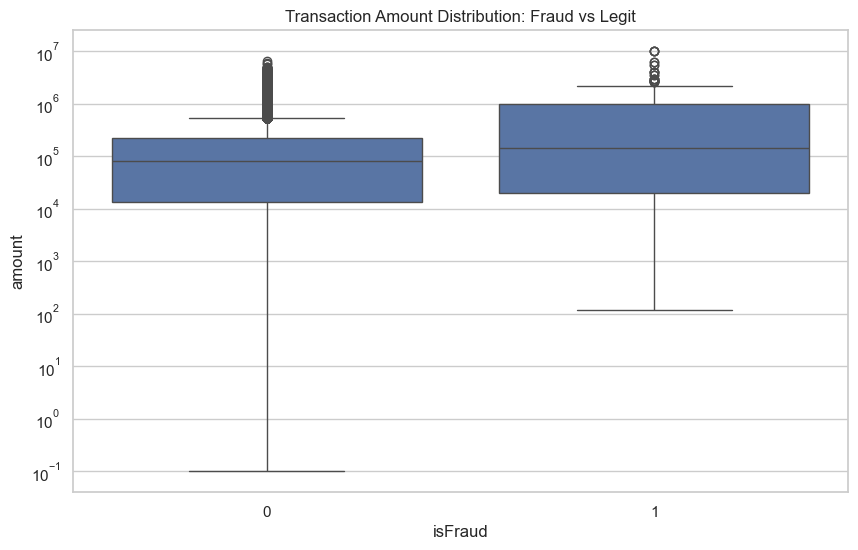

In [25]:
# Let's compare the amount spent in Fraud vs Legit transactions
plt.figure(figsize=(10, 6))
sns.boxplot(x='isFraud', y='amount', data=df)
plt.title('Transaction Amount Distribution: Fraud vs Legit')
plt.yscale('log') # Using log scale because amounts vary wildly
plt.show()

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Just making plots look nicer
sns.set_theme(style="whitegrid")
print("Libraries loaded ✅")

Libraries loaded ✅


In [27]:
# nrows=500000 is smart — PaySim has ~6.3M rows
# We work on 500k for speed, will use full data for final model training
df = pd.read_csv('../dataset/paysim_data.csv', nrows=500000)
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Shape: (500000, 11)
Columns: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']


In [28]:
# Always check dtypes — 'type' column is object (string), needs encoding later
df.dtypes

step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

In [29]:
print("=== NULL VALUES ===")
print(df.isnull().sum())
print(f"\n=== DUPLICATES ===")
print(f"Duplicate rows: {df.duplicated().sum()}")
# PaySim has NO nulls and NO duplicates — good synthetic dataset

=== NULL VALUES ===
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

=== DUPLICATES ===
Duplicate rows: 0


In [30]:
fraud_count = df['isFraud'].value_counts()
fraud_pct   = (fraud_count[1] / len(df)) * 100

print(f"Total transactions : {len(df):,}")
print(f"Fraudulent         : {fraud_count[1]:,}")
print(f"Legitimate         : {fraud_count[0]:,}")
print(f"Fraud percentage   : {fraud_pct:.4f}%")

# You'll notice: ~0.12% fraud — EXTREMELY imbalanced
# This is why you can't just use accuracy as your metric
# A model that says "never fraud" gets 99.88% accuracy — useless!

Total transactions : 500,000
Fraudulent         : 233
Legitimate         : 499,767
Fraud percentage   : 0.0466%


In [31]:
print("=== Transactions by type ===")
print(df['type'].value_counts())

print("\n=== FRAUD by transaction type ===")
fraud_by_type = df.groupby('type')['isFraud'].agg(['sum', 'mean'])
fraud_by_type.columns = ['fraud_count', 'fraud_rate']
fraud_by_type['fraud_rate'] = (fraud_by_type['fraud_rate'] * 100).round(4)
print(fraud_by_type.sort_values('fraud_count', ascending=False))

# KEY INSIGHT: Fraud ONLY happens in TRANSFER and CASH_OUT
# This means we can immediately filter out PAYMENT, CASH_IN, DEBIT

=== Transactions by type ===
type
CASH_OUT    182316
PAYMENT     164032
CASH_IN     109319
TRANSFER     40730
DEBIT         3603
Name: count, dtype: int64

=== FRAUD by transaction type ===
          fraud_count  fraud_rate
type                             
CASH_OUT          121      0.0664
TRANSFER          112      0.2750
CASH_IN             0      0.0000
DEBIT               0      0.0000
PAYMENT             0      0.0000


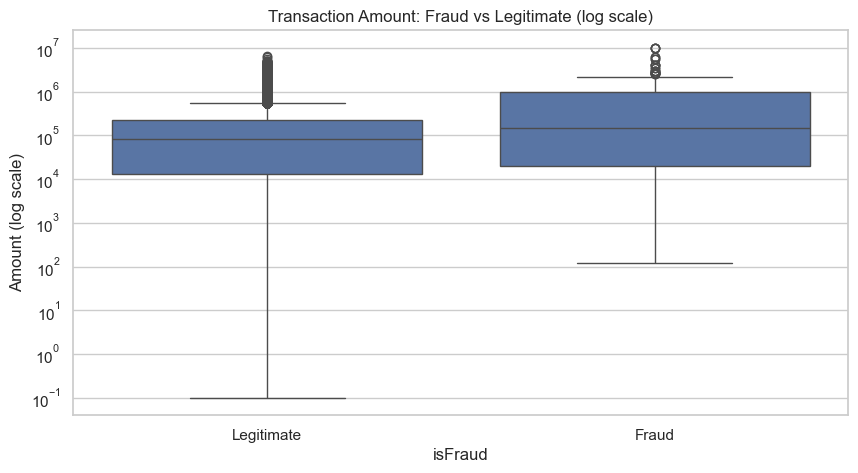

In [32]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='isFraud', y='amount', data=df)
plt.yscale('log')
plt.xticks([0, 1], ['Legitimate', 'Fraud'])
plt.title('Transaction Amount: Fraud vs Legitimate (log scale)')
plt.ylabel('Amount (log scale)')
plt.show()
# Fraud transactions tend to be LARGER — important feature

In [33]:
# PaySim 'step' = hours since simulation start (1 to 744 = 31 days)
# We need hour-of-day for our model
df['hour'] = df['step'] % 24
df['day']  = df['step'] // 24

print(f"Step range: {df['step'].min()} to {df['step'].max()}")
print(f"Hour range: {df['hour'].min()} to {df['hour'].max()}")
print(f"Day range : {df['day'].min()} to {df['day'].max()}")

Step range: 1 to 20
Hour range: 1 to 20
Day range : 0 to 0


In [34]:
# Save key insight as a comment for future reference
summary = {
    'total_rows'       : len(df),
    'fraud_count'      : int(fraud_count[1]),
    'fraud_pct'        : round(fraud_pct, 4),
    'fraud_types_only' : ['TRANSFER', 'CASH_OUT'],
    'columns'          : list(df.columns),
    'no_nulls'         : True,
}
print("Summary:", summary)

Summary: {'total_rows': 500000, 'fraud_count': 233, 'fraud_pct': np.float64(0.0466), 'fraud_types_only': ['TRANSFER', 'CASH_OUT'], 'columns': ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud', 'hour', 'day'], 'no_nulls': True}
